# EXP_v5: D-optimality vs DQN vs Random RMSE comparison

`EXP_v5/results/` に保存されたsummary CSVを読み込み、D-optimality、DQN、ランダムベースラインのステップ別RMSEを比較します。指定したbank・能力相関・epsilonに一致するDQNのgammaを自動検出し、同じbank・能力相関・項目数のRandom summaryを読み込みます。

主図では2次元全体の `RMSE_overall` を比較し、補助図では `RMSE_theta1`、`RMSE_theta2`、`RMSE_overall` を3パネルで比較します。

In [1]:
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for root in [cwd, *cwd.parents]:
        if (root / "EXP_v5" / "results").is_dir():
            return root
    raise FileNotFoundError(
        "Could not find the project root containing EXP_v5/results."
    )


@dataclass(frozen=True)
class Config:
    bank_id: int = 1
    rho: float = 0.0
    n_items: int = 150
    epsilon: float = 0.1
    test_length: int = 40
    key_steps: tuple[int, ...] = (10, 20, 30, 40)


RHO_TAGS = {0.0: "rho00", 0.3: "rho03", 0.6: "rho06"}
RMSE_COLUMNS = ("RMSE_theta1", "RMSE_theta2", "RMSE_overall")
ROOT = find_project_root()
RESULTS_DIR = ROOT / "EXP_v5" / "results"

cfg = Config(
    bank_id=1,
    rho=0.0,
    n_items=150,
    epsilon=0.1,
    test_length=40,
    key_steps=(10, 20, 30, 40),
)

if cfg.rho not in RHO_TAGS:
    raise ValueError(f"rho must be one of {tuple(RHO_TAGS)}.")
if cfg.bank_id < 1 or cfg.n_items < 1 or cfg.test_length < 1:
    raise ValueError("bank_id, n_items, and test_length must be positive.")
if any(step < 1 or step > cfg.test_length for step in cfg.key_steps):
    raise ValueError("Every key step must be within the test length.")

rho_tag = RHO_TAGS[cfg.rho]
epsilon_label = format(cfg.epsilon, "g")
condition_stem = f"2d_2pl_uncor_{cfg.bank_id}_{rho_tag}_{cfg.n_items}items"

print(f"Project root: {ROOT}")
print(f"Results dir : {RESULTS_DIR}")
print(f"Condition   : {condition_stem}, epsilon={epsilon_label}")

Project root: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History
Results dir : /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP_v5/results
Condition   : 2d_2pl_uncor_1_rho00_150items, epsilon=0.1


In [2]:
REQUIRED_COLUMNS = {"step", *RMSE_COLUMNS}


def read_summary(path: Path) -> pd.DataFrame:
    if not path.is_file():
        raise FileNotFoundError(f"Summary CSV not found: {path}")

    frame = pd.read_csv(path)
    missing = REQUIRED_COLUMNS - set(frame.columns)
    if missing:
        raise ValueError(f"{path.name} is missing columns: {sorted(missing)}")

    frame = frame.copy()
    step_values = pd.to_numeric(frame["step"], errors="raise")
    rounded_steps = step_values.round().astype(int)
    if not np.allclose(step_values, rounded_steps):
        raise ValueError(f"{path.name} contains non-integer step values.")
    frame["step"] = rounded_steps
    if frame["step"].duplicated().any():
        raise ValueError(f"{path.name} contains duplicate step values.")

    expected_steps = set(range(1, cfg.test_length + 1))
    if set(frame["step"]) != expected_steps:
        raise ValueError(
            f"{path.name} must contain exactly steps 1 through {cfg.test_length}."
        )

    rmse_values = frame[list(RMSE_COLUMNS)].to_numpy(dtype=float)
    if not np.isfinite(rmse_values).all():
        raise ValueError(f"{path.name} contains non-finite RMSE values.")
    if (rmse_values < 0).any():
        raise ValueError(f"{path.name} contains negative RMSE values.")
    return frame.sort_values("step").reset_index(drop=True)


def gamma_sort_key(gamma: str) -> tuple[int, float | str]:
    try:
        return (0, float(gamma))
    except ValueError:
        return (1, gamma)


d_optimality_path = (
    RESULTS_DIR / f"summary_{condition_stem}_D_optimality_MAP_python.csv"
)
d_optimality = read_summary(d_optimality_path)

random_path = RESULTS_DIR / f"summary_{condition_stem}_Random_MAP_python.csv"
random_baseline = read_summary(random_path)

dqn_prefix = f"summary_{condition_stem}_DQN_MAP_epsilon_{epsilon_label}_gamma_"
dqn_runs: dict[str, pd.DataFrame] = {}
dqn_paths: dict[str, Path] = {}
for path in sorted(RESULTS_DIR.glob(f"{dqn_prefix}*.csv")):
    gamma = path.stem.removeprefix(dqn_prefix)
    if not gamma:
        continue
    if gamma in dqn_runs:
        raise ValueError(f"Duplicate DQN summary for gamma={gamma}: {path}")
    dqn_runs[gamma] = read_summary(path)
    dqn_paths[gamma] = path

if not dqn_runs:
    raise FileNotFoundError(
        f"No DQN summaries matched {dqn_prefix}*.csv in {RESULTS_DIR}."
    )

sorted_gammas = sorted(dqn_runs, key=gamma_sort_key)
print(f"D-optimality: {d_optimality_path.name}")
print(f"Random       : {random_path.name}")
for gamma in sorted_gammas:
    print(f"DQN gamma={gamma}: {dqn_paths[gamma].name}")

D-optimality: summary_2d_2pl_uncor_1_rho00_150items_D_optimality_MAP_python.csv
Random       : summary_2d_2pl_uncor_1_rho00_150items_Random_MAP_python.csv
DQN gamma=0.1: summary_2d_2pl_uncor_1_rho00_150items_DQN_MAP_epsilon_0.1_gamma_0.1.csv
DQN gamma=0.3: summary_2d_2pl_uncor_1_rho00_150items_DQN_MAP_epsilon_0.1_gamma_0.3.csv
DQN gamma=0.5: summary_2d_2pl_uncor_1_rho00_150items_DQN_MAP_epsilon_0.1_gamma_0.5.csv


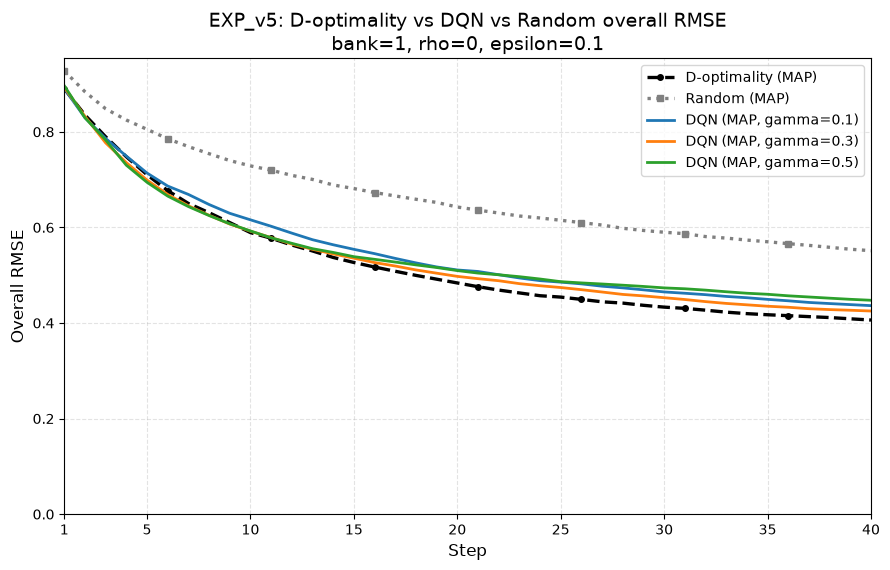

Saved overall RMSE figure to: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP_v5/results/rmse_overall_comparison_2d_2pl_uncor_1_rho00_150items_D_optimality_vs_DQN_vs_Random.png


In [3]:
colors = {
    gamma: plt.get_cmap("tab10")(index) for index, gamma in enumerate(sorted_gammas)
}
x_ticks = sorted({1, *range(5, cfg.test_length + 1, 5), cfg.test_length})

overall_figure, overall_axis = plt.subplots(figsize=(9, 5.8))
overall_axis.plot(
    d_optimality["step"],
    d_optimality["RMSE_overall"],
    color="black",
    linestyle="--",
    marker="o",
    markevery=5,
    markersize=4,
    linewidth=2.4,
    label="D-optimality (MAP)",
)
overall_axis.plot(
    random_baseline["step"],
    random_baseline["RMSE_overall"],
    color="gray",
    linestyle=":",
    marker="s",
    markevery=5,
    markersize=4,
    linewidth=2.4,
    label="Random (MAP)",
)
for gamma in sorted_gammas:
    curve = dqn_runs[gamma]
    overall_axis.plot(
        curve["step"],
        curve["RMSE_overall"],
        color=colors[gamma],
        linewidth=2.0,
        label=f"DQN (MAP, gamma={gamma})",
    )

overall_axis.set_title(
    f"EXP_v5: D-optimality vs DQN vs Random overall RMSE\n"
    f"bank={cfg.bank_id}, rho={cfg.rho:g}, epsilon={epsilon_label}",
    fontsize=14,
)
overall_axis.set_xlabel("Step", fontsize=12)
overall_axis.set_ylabel("Overall RMSE", fontsize=12)
overall_axis.set_xlim(1, cfg.test_length)
overall_axis.set_ylim(bottom=0)
overall_axis.set_xticks(x_ticks)
overall_axis.grid(True, linestyle="--", alpha=0.35)
overall_axis.legend(fontsize=10)
overall_figure.tight_layout()

overall_path = (
    RESULTS_DIR
    / f"rmse_overall_comparison_{condition_stem}_D_optimality_vs_DQN_vs_Random.png"
)
overall_figure.savefig(overall_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved overall RMSE figure to: {overall_path}")

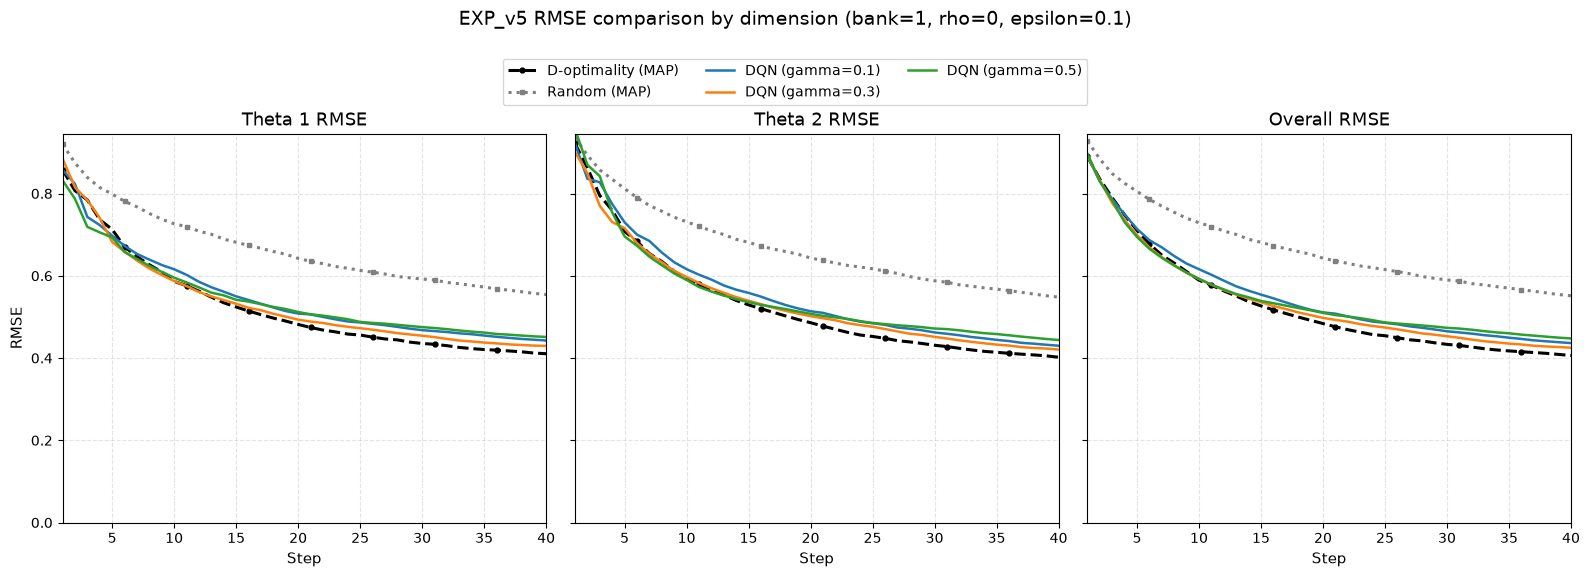

Saved dimension RMSE figure to: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP_v5/results/rmse_by_dimension_comparison_2d_2pl_uncor_1_rho00_150items_D_optimality_vs_DQN_vs_Random.png


In [4]:
panel_titles = {
    "RMSE_theta1": "Theta 1 RMSE",
    "RMSE_theta2": "Theta 2 RMSE",
    "RMSE_overall": "Overall RMSE",
}
dimension_figure, dimension_axes = plt.subplots(
    1, 3, figsize=(16, 5.2), sharex=True, sharey=True
)
for axis, metric in zip(dimension_axes, RMSE_COLUMNS):
    axis.plot(
        d_optimality["step"],
        d_optimality[metric],
        color="black",
        linestyle="--",
        marker="o",
        markevery=5,
        markersize=3.5,
        linewidth=2.2,
        label="D-optimality (MAP)",
    )
    axis.plot(
        random_baseline["step"],
        random_baseline[metric],
        color="gray",
        linestyle=":",
        marker="s",
        markevery=5,
        markersize=3.5,
        linewidth=2.2,
        label="Random (MAP)",
    )
    for gamma in sorted_gammas:
        curve = dqn_runs[gamma]
        axis.plot(
            curve["step"],
            curve[metric],
            color=colors[gamma],
            linewidth=1.8,
            label=f"DQN (gamma={gamma})",
        )
    axis.set_title(panel_titles[metric], fontsize=13)
    axis.set_xlabel("Step", fontsize=11)
    axis.set_xlim(1, cfg.test_length)
    axis.set_ylim(bottom=0)
    axis.xaxis.set_major_locator(mticker.MultipleLocator(5))
    axis.grid(True, linestyle="--", alpha=0.35)

dimension_axes[0].set_ylabel("RMSE", fontsize=11)
handles, labels = dimension_axes[0].get_legend_handles_labels()
dimension_figure.legend(
    handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02)
)
dimension_figure.suptitle(
    f"EXP_v5 RMSE comparison by dimension "
    f"(bank={cfg.bank_id}, rho={cfg.rho:g}, epsilon={epsilon_label})",
    fontsize=14,
    y=1.10,
)
dimension_figure.tight_layout()

dimension_path = (
    RESULTS_DIR
    / f"rmse_by_dimension_comparison_{condition_stem}_D_optimality_vs_DQN_vs_Random.png"
)
dimension_figure.savefig(dimension_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved dimension RMSE figure to: {dimension_path}")

In [5]:
def overall_rmse_at(frame: pd.DataFrame, step: int) -> float:
    selected = frame.loc[frame["step"] == step, "RMSE_overall"]
    if len(selected) != 1:
        raise ValueError(f"Expected exactly one RMSE value at step {step}.")
    return float(selected.iloc[0])


rows = [
    {
        "method": "D-optimality (MAP)",
        **{
            f"step_{step}": overall_rmse_at(d_optimality, step)
            for step in cfg.key_steps
        },
        "mean_step_1_to_40": float(d_optimality["RMSE_overall"].mean()),
    },
    {
        "method": "Random (MAP)",
        **{
            f"step_{step}": overall_rmse_at(random_baseline, step)
            for step in cfg.key_steps
        },
        "mean_step_1_to_40": float(random_baseline["RMSE_overall"].mean()),
    },
]
for gamma in sorted_gammas:
    curve = dqn_runs[gamma]
    rows.append(
        {
            "method": f"DQN (MAP, gamma={gamma})",
            **{f"step_{step}": overall_rmse_at(curve, step) for step in cfg.key_steps},
            "mean_step_1_to_40": float(curve["RMSE_overall"].mean()),
        }
    )

key_step_comparison = pd.DataFrame(rows).set_index("method")
display(key_step_comparison.style.format("{:.4f}"))

,step_10,step_20,step_30,step_40,mean_step_1_to_40
method,,,,,
D-optimality (MAP),0.5892,0.4838,0.4332,0.4062,0.5271
Random (MAP),0.7288,0.6427,0.5899,0.5513,0.6666
"DQN (MAP, gamma=0.1)",0.6159,0.5110,0.4650,0.4363,0.5516
"DQN (MAP, gamma=0.3)",0.5921,0.4976,0.4529,0.4251,0.5371
"DQN (MAP, gamma=0.5)",0.5926,0.5097,0.4734,0.4476,0.5482
